#### 1) Importing Necessary Libraries:

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from prophet import Prophet

#### 2) Loading Data:

In [2]:
df = pd.read_csv('BeerWineLiquor.csv')

In [3]:
df.head()

,date,beer
0,1/1/1992,1509
1,2/1/1992,1541
2,3/1/1992,1597
3,4/1/1992,1675
4,5/1/1992,1822


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 324 entries, 0 to 323
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   date    324 non-null    object
 1   beer    324 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 5.2+ KB


In [5]:
# Changing 'date' column to Date-Time Datatype:

df['date'] = pd.to_datetime(df['date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 324 entries, 0 to 323
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    324 non-null    datetime64[ns]
 1   beer    324 non-null    int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 5.2 KB


##### Formatting Data as per Prophet Library needs:

In [6]:
df.columns = ['ds', 'y']

In [7]:
df.head()

,ds,y
0,1992-01-01,1509
1,1992-02-01,1541
2,1992-03-01,1597
3,1992-04-01,1675
4,1992-05-01,1822


#### 3) Fitting Prophet Model and Forecasting:

In [8]:
m = Prophet()
m.fit(df)

19:06:34 - cmdstanpy - INFO - Chain [1] start processing
19:06:34 - cmdstanpy - INFO - Chain [1] done processing


##### Forecast:

In [9]:
future_df = m.make_future_dataframe(periods= 24,
                                   freq= 'MS')

In [10]:
future_df.head()

,ds
0,1992-01-01
1,1992-02-01
2,1992-03-01
3,1992-04-01
4,1992-05-01


In [12]:
future_df.tail()

,ds
343,2020-08-01
344,2020-09-01
345,2020-10-01
346,2020-11-01
347,2020-12-01


##### Using Model to Forecast:

In [14]:
forecast = m.predict(future_df)

In [15]:
forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,1992-01-01,1763.763947,1140.295091,1460.980048,1763.763947,1763.763947,-461.318162,-461.318162,-461.318162,-461.318162,-461.318162,-461.318162,0.0,0.0,0.0,1302.445785
1,1992-02-01,1766.914279,1172.496164,1509.660475,1766.914279,1766.914279,-426.414899,-426.414899,-426.414899,-426.414899,-426.414899,-426.414899,0.0,0.0,0.0,1340.499381
2,1992-03-01,1769.861364,1422.537648,1760.689631,1769.861364,1769.861364,-178.480362,-178.480362,-178.480362,-178.480362,-178.480362,-178.480362,0.0,0.0,0.0,1591.381002
3,1992-04-01,1773.011696,1413.600687,1736.717510,1773.011696,1773.011696,-196.071290,-196.071290,-196.071290,-196.071290,-196.071290,-196.071290,0.0,0.0,0.0,1576.940406
4,1992-05-01,1776.060405,1655.059882,1977.144526,1776.060405,1776.060405,44.753578,44.753578,44.753578,44.753578,44.753578,44.753578,0.0,0.0,0.0,1820.813983


In [16]:
forecast[['yhat', 'yhat_lower', 'yhat_upper']].head()

,yhat,yhat_lower,yhat_upper
0,1302.445785,1140.295091,1460.980048
1,1340.499381,1172.496164,1509.660475
2,1591.381002,1422.537648,1760.689631
3,1576.940406,1413.600687,1736.717510
4,1820.813983,1655.059882,1977.144526


##### Plotting Forecast:

<Figure size 1500x600 with 0 Axes>

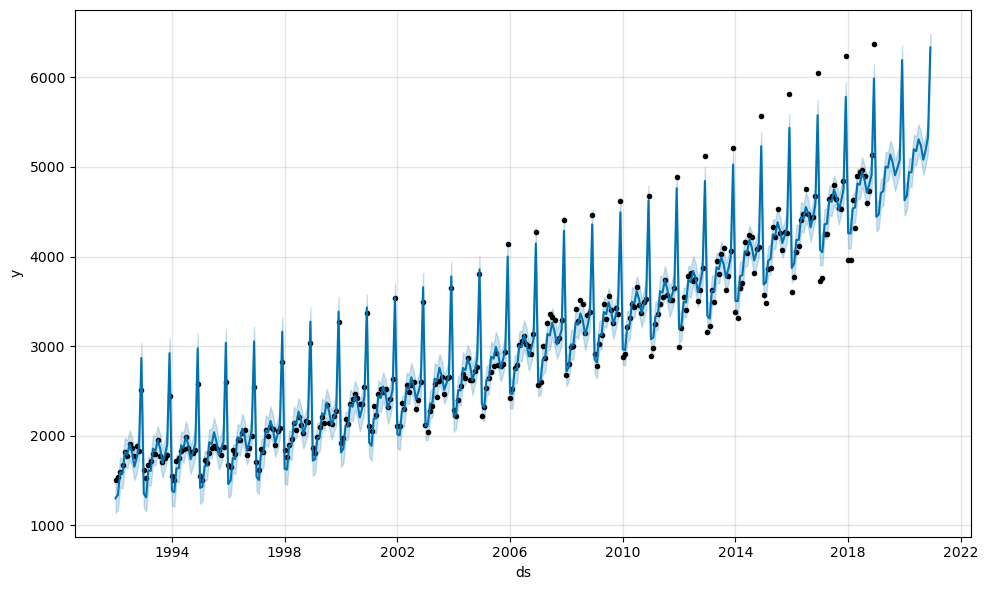

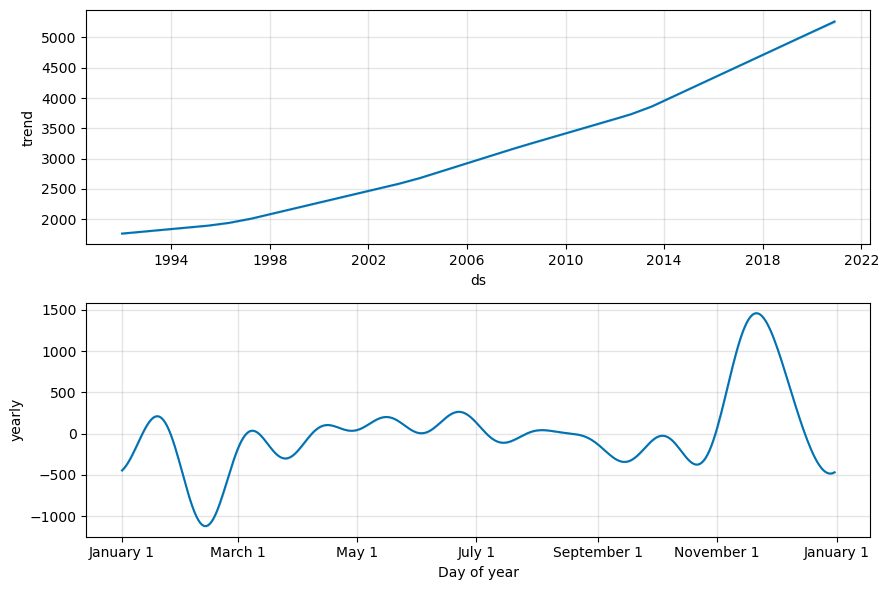

In [18]:
plt.figure(figsize= (15,6))
m.plot(forecast)
m.plot_components(forecast)
plt.show()